In [1]:
from fiqci.ems import FiQCIEstimator
from iqm.qiskit_iqm import IQMProvider
from qiskit import QuantumCircuit, transpile
from qiskit.quantum_info import SparsePauliOp

In [2]:
url = None
quantum_computer = None

# Connect to an IQM quantum computer using the provider
if url is not None and quantum_computer is not None:
	provider = IQMProvider(url=url, quantum_computer=quantum_computer)
	backend = provider.get_backend()
else:
	# Or using a noisy simulator
	from iqm.qiskit_iqm import IQMFakeAdonis

	backend = IQMFakeAdonis()

# Initialise FiQCI estimator with mitigation level 3 (readout error mitigation + zero-noise extrapolation)
estimator = FiQCIEstimator(backend=backend, mitigation_level=3)

# We can view the default settings enabled for mitigation level 3
estimator.mitigator_options

/home/runner/work/fiqci-ems/fiqci-ems/src/fiqci/ems/fiqci_backend.py:89: UserWarning: Mitigation level 2 (M3 + Dynamical Decoupling) not implemented yet. Level 2 will currently only apply M3 readout error mitigation without dynamical decoupling.
  warnings.warn(


{'zne': {'enabled': True,
  'fold_gates': None,
  'scale_factors': [1, 3, 5],
  'folding_method': 'local',
  'extrapolation_method': 'exponential',
  'extrapolation_degree': None},
 'rem': {'enabled': True,
  'calibration_shots': 1000,
  'calibration_file': None,
  'mitigator': <fiqci.ems.mitigators.rem.M3IQM at 0x7fd00f95fb00>}}

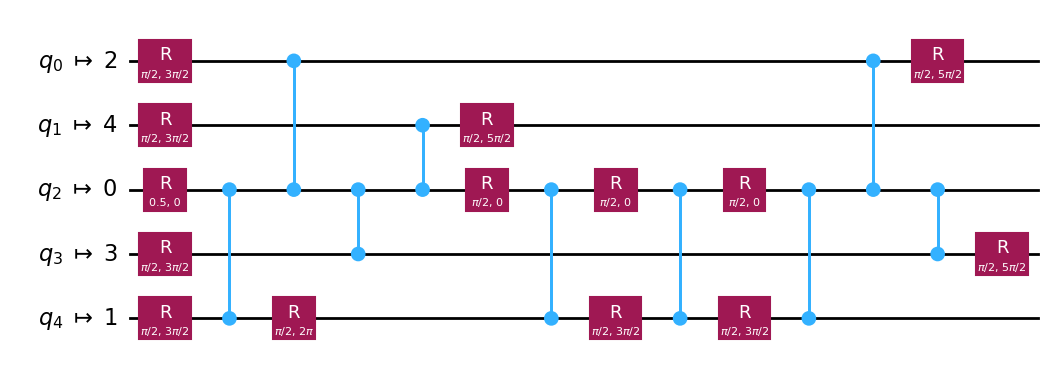

In [3]:
# Define a simple 5-qubit circuit
qc = QuantumCircuit(5)
qc.rx(0.5, 0)
qc.cx(0, 1)
qc.cx(0, 2)
qc.cx(0, 3)
qc.cx(0, 4)
qc.cx(1, 2)
qc.cx(1, 3)

# Transpile for backend
qc_transpiled = transpile(qc, backend=backend)

qc_transpiled.draw("mpl")

In [4]:
# Define observables to calculate expectation values for (here Z on each qubit)
observables = SparsePauliOp.from_list([("ZIIII", 1), ("IZIII", 1), ("IIZII", 1), ("IIIZI", 1), ("IIIIZ", 1)])

# Map observables to the layout of the transpiled circuit
observables_device = observables.apply_layout(qc_transpiled.layout)

# Execute on FiQCI Estimator with specified observables and shots
job = estimator.run([qc_transpiled], observables=observables_device, shots=2**10)

# Retrieve mitigated expectation values
job.expectation_values()

[[0.7732596199881374,
  0.7732596199881374,
  0.7732596199881374,
  0.7732596199881374,
  0.7732596199881374]]

In [5]:
# Initialise FiQCI estimator
estimator = FiQCIEstimator(backend=backend, mitigation_level=0)

# Configure ZNE
estimator.zne(enabled=True, scale_factors=[1, 5], extrapolation_method="richardson", folding_method="global")

# Print ZNE settings
estimator.mitigator_options

{'zne': {'enabled': True,
  'fold_gates': None,
  'scale_factors': [1, 5],
  'folding_method': 'local',
  'extrapolation_method': 'richardson',
  'extrapolation_degree': None},
 'rem': {'enabled': False,
  'calibration_shots': 1000,
  'calibration_file': None,
  'mitigator': None}}

In [6]:
# Execute the same circuit as above with only ZNE enabled (no readout error mitigation)
job = estimator.run([qc_transpiled], observables=observables_device, shots=2**10)
job.expectation_values()

[[0.76513671875, 0.76513671875, 0.76513671875, 0.76513671875, 0.76513671875]]

In [7]:
# Estimator may execute multiple circuits depending on observables and mitigator settings. Here we fecth them all as a list
jobs = job.jobs()

# Look at the first job
job0 = jobs[0]

# Get the counts for the first job
print(job0.result().get_counts())

[{'10101': 1, '11101': 3, '11110': 23, '01100': 4, '01000': 51, '10011': 12, '00101': 1, '10001': 10, '01001': 7, '11010': 1, '01110': 46, '01101': 1, '10000': 49, '00100': 35, '00010': 20, '11001': 50, '00000': 633, '00110': 3, '00001': 24, '10010': 3, '00011': 4, '00111': 2, '10110': 3, '10111': 12, '10100': 1, '01010': 10, '01111': 3, '11000': 6, '11011': 3, '11111': 2, '01011': 1}, {'11000': 10, '01111': 11, '11110': 51, '10000': 82, '10110': 12, '10010': 17, '11100': 6, '00110': 12, '00001': 32, '10101': 11, '00010': 29, '11001': 41, '00000': 247, '11010': 22, '10001': 28, '01001': 21, '00101': 8, '11101': 18, '01110': 88, '01010': 35, '01011': 5, '00100': 51, '10111': 37, '10100': 23, '10011': 32, '01100': 12, '01000': 33, '01101': 9, '00011': 5, '00111': 12, '11011': 11, '11111': 13}]
